# Seasonal Agriculture Performance Analysis

### VOIS AICTE Batch 1 2026–2027

**Major Project**

### Objective

The objective of this project is to analyze agricultural performance across different seasons and identify meaningful patterns in yield, profitability, resource usage, environmental conditions and agricultural risk.

The analysis focuses mainly on the Kharif, Rabi and Zaid seasons.


## 1. Importing Required Libraries

In this section, I import the Python libraries required for data analysis, visualization and statistical testing.

- Pandas and NumPy are used for data manipulation and numerical operations.
- Matplotlib is used to create visualizations.
- SciPy is used for statistical analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("Libraries imported successfully!")

Libraries imported successfully!


### Observation

All the required libraries were imported successfully without errors. These libraries will be used throughout the analysis.

## 1. Importing Required Libraries

In this section, I import the Python libraries required for data analysis, visualization and statistical testing.

- Pandas and NumPy are used for data manipulation and numerical operations.
- Matplotlib is used to create visualizations.
- SciPy is used for statistical analysis.

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


### Observation

The dataset was loaded successfully.

The dataset contains **4,000 records and 28 columns**, representing different agricultural, environmental, resource and economic characteristics.

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

### Observation

The dataset contains both categorical and numerical variables.

Categorical variables include State, District, Crop, Season and Irrigation Method, while most measurements such as rainfall, temperature, yield, cost and profit are numerical.

In [6]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [7]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


### Observation

Missing values are present in the Rainfall, Soil Moisture and Yield variables.

These missing observations need to be handled before continuing with the analysis.

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
clean = df.copy()

for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    clean[col] = clean[col].fillna(clean[col].median())

print("Remaining missing values:", clean.isnull().sum().sum())

Remaining missing values: 0


### Observation

After applying median imputation, there are no remaining missing values in the dataset.

The cleaned dataset can now be used for further analysis.

In [26]:
duplicate_count = clean.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

if duplicate_count > 0:
    clean = clean.drop_duplicates().reset_index(drop=True)
    print("Duplicate records removed.")
else:
    print("No duplicate records found. No removal required.")

Number of duplicate records: 0
No duplicate records found. No removal required.


### Observation

The duplicate check was completed successfully.

If duplicate records were present, they were removed. If no duplicates were found, the dataset was retained without modification.

## 10. Outlier Investigation

Outliers are observations that are unusually high or low compared with the majority of the data.

In agricultural data, extreme values may represent genuine farming conditions. Therefore, I will investigate the outliers rather than automatically deleting them.

In [27]:
numeric_columns = [
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Used_m3",
    "Rainfall_mm"
]

for column in numeric_columns:

    Q1 = clean[column].quantile(0.25)
    Q3 = clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = clean[
        (clean[column] < lower_limit) |
        (clean[column] > upper_limit)
    ]

    print("Variable:", column)
    print("Number of outliers:", len(outliers))
    print("Lower limit:", round(lower_limit, 2))
    print("Upper limit:", round(upper_limit, 2))
    print()

Variable: Yield_Tonnes_Ha
Number of outliers: 302
Lower limit: -1.62
Upper limit: 5.5

Variable: Profit_INR
Number of outliers: 404
Lower limit: -696111.0
Upper limit: 763567.0

Variable: Water_Used_m3
Number of outliers: 276
Lower limit: -6072.75
Upper limit: 16171.25

Variable: Rainfall_mm
Number of outliers: 0
Lower limit: -319.02
Upper limit: 1522.57



### Observation

The IQR method identified observations that fall outside the normal range for the selected variables.

These observations were investigated but not automatically removed because extreme agricultural values may represent genuine differences between farms, environmental conditions or production levels.

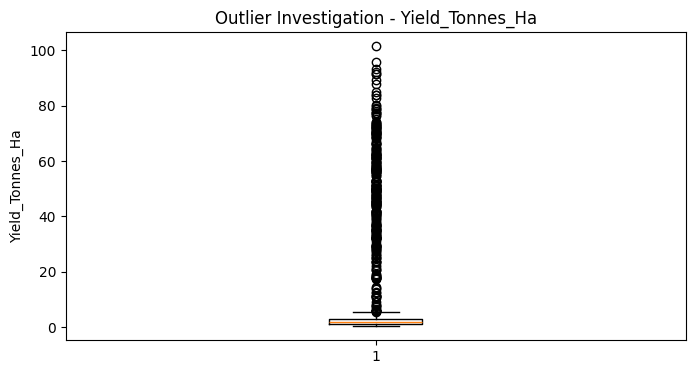

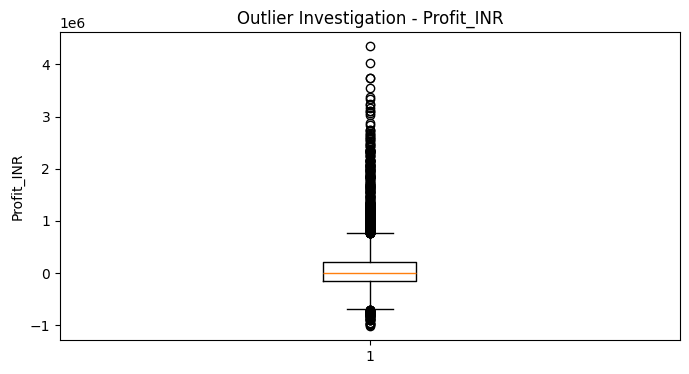

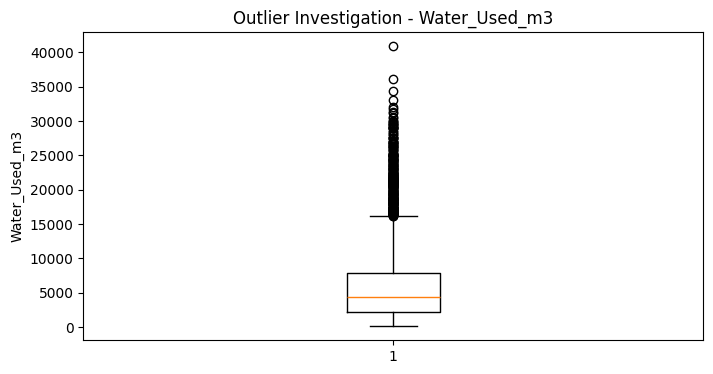

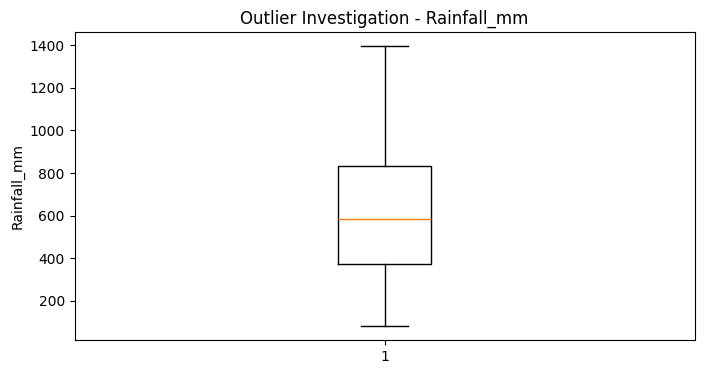

In [28]:
for column in numeric_columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(clean[column].dropna())

    plt.title("Outlier Investigation - " + column)
    plt.ylabel(column)

    plt.show()

### Observation

The boxplots provide a visual representation of the spread and extreme observations in the selected variables.

The identified extreme observations are retained because they may contain meaningful agricultural information.

## 11. Univariate Analysis

Univariate analysis examines one variable at a time.

Here, I will study the distribution of agricultural yield to understand its overall pattern.

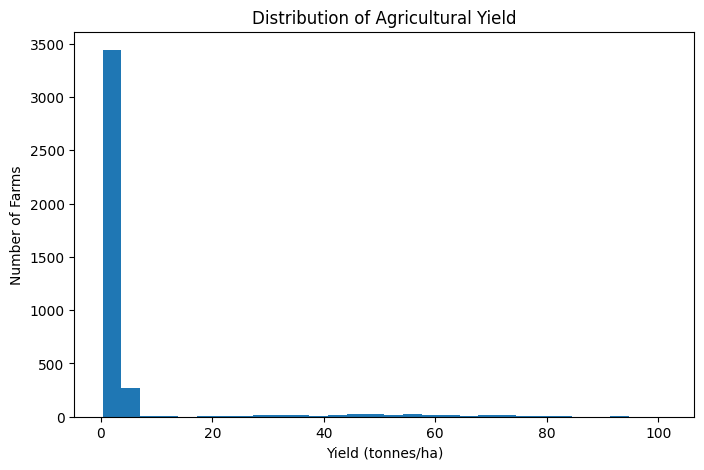

In [29]:
plt.figure(figsize=(8, 5))

plt.hist(clean["Yield_Tonnes_Ha"], bins=30)

plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Number of Farms")

plt.show()

### Observation

The histogram shows how agricultural yield is distributed across the farms.

Most observations are concentrated in the lower-to-middle yield range, while some observations have substantially higher yields.

In [10]:
clean["Season"].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


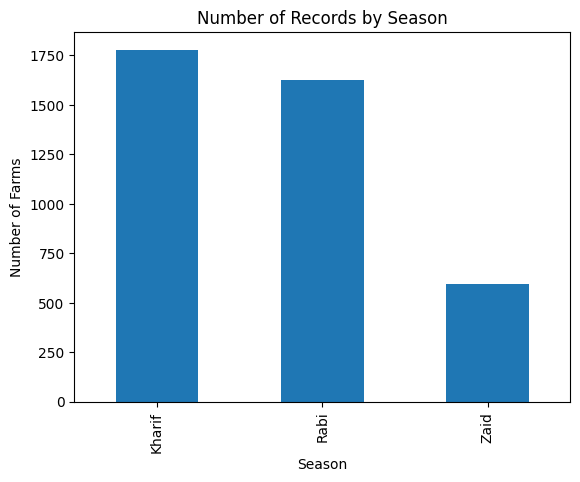

In [11]:
clean["Season"].value_counts().plot(kind="bar")

plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.show()

### Observation

Kharif has the largest number of observations, followed by Rabi, while Zaid has fewer records.

Therefore, seasonal comparisons should consider that the number of observations is not identical across seasons.

In [12]:
season_order = ["Kharif", "Rabi", "Zaid"]

season_yield = (
    clean.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .reindex(season_order)
)

season_yield

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


### Observation

The average yield differs across Kharif, Rabi and Zaid.

Kharif records the highest average yield, followed by Rabi, while Zaid records the lowest average yield.

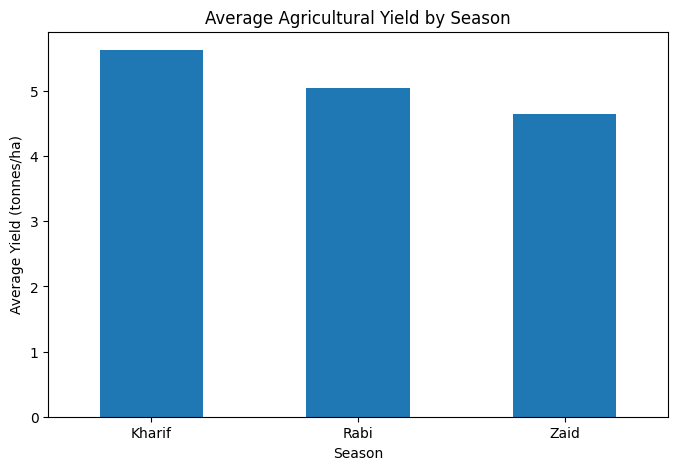

In [13]:
plt.figure(figsize=(8,5))

season_yield.plot(kind="bar")

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=0)

plt.show()

### Interpretation

The chart shows that Kharif has the strongest average yield performance, while Zaid has the lowest average yield.

This suggests that seasonal conditions may be associated with differences in agricultural productivity.

In [31]:
multivariate_analysis = clean.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Temperature=("Avg_Temperature_C", "mean")
).reindex(season_order)

multivariate_analysis.round(2)

,Average_Yield,Average_Profit,Average_Water_Efficiency,Average_Rainfall,Average_Temperature
Season,,,,,
Kharif,5.63,178914.65,5.89,849.20,28.45
Rabi,5.04,87689.47,5.19,437.62,23.49
Zaid,4.64,-24804.82,4.41,304.65,31.04


### Observation

The multivariate comparison shows that agricultural performance is influenced by several dimensions.

Yield, profitability, water efficiency and environmental conditions differ between seasons, so agricultural performance should not be evaluated using yield alone.

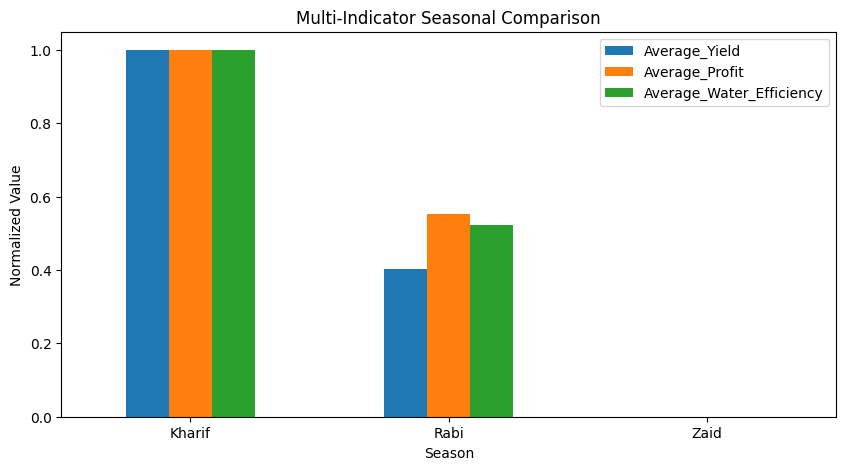

In [32]:
plot_data = multivariate_analysis[
    ["Average_Yield", "Average_Profit", "Average_Water_Efficiency"]
].copy()

plot_data = (
    plot_data - plot_data.min()
) / (
    plot_data.max() - plot_data.min()
)

plot_data.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Multi-Indicator Seasonal Comparison")
plt.xlabel("Season")
plt.ylabel("Normalized Value")
plt.xticks(rotation=0)

plt.show()

### Interpretation

The normalized comparison makes it possible to examine several performance indicators together.

The results demonstrate that the strongest season for one indicator does not necessarily have the same ranking for every other indicator.

In [14]:
crop_summary = (
    clean.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

crop_summary

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


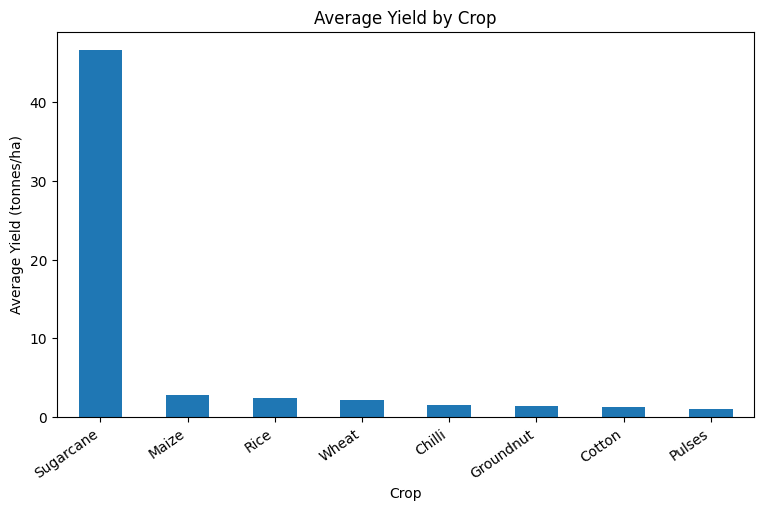

In [15]:
plt.figure(figsize=(9,5))

crop_summary.plot(kind="bar")

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=35, ha="right")

plt.show()

In [16]:
irrigation_summary = clean.groupby("Irrigation_Method").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
)

irrigation_summary

,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency
Irrigation_Method,,,,
Drip,6.577989,219625.997814,5918.747541,6.267129
Flood,4.863977,73354.022901,8026.472519,3.438853
Rainfed,4.602142,79050.365034,3549.554275,7.563784
Sprinkler,5.160627,91121.079019,6208.258856,4.669805


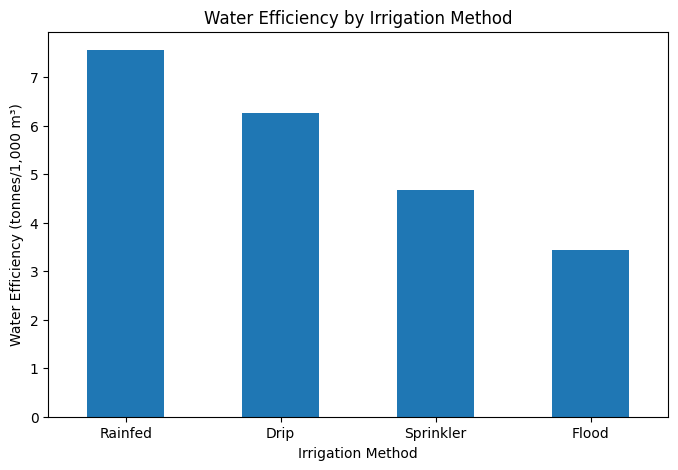

In [17]:
plt.figure(figsize=(8,5))

irrigation_summary["Average_Water_Efficiency"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (tonnes/1,000 m³)")
plt.xticks(rotation=0)

plt.show()

### Visualizing the Correlation

A scatter plot will help visualize the relationship between yield and water efficiency.

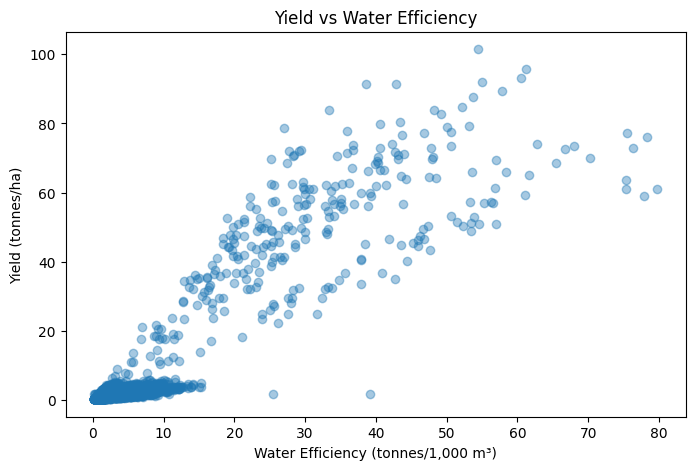

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    clean["Water_Efficiency_t_per_1000m3"],
    clean["Yield_Tonnes_Ha"],
    alpha=0.4
)

plt.title("Yield vs Water Efficiency")
plt.xlabel("Water Efficiency (tonnes/1,000 m³)")
plt.ylabel("Yield (tonnes/ha)")

plt.show()

In [19]:
correlation = clean[
    ["Yield_Tonnes_Ha", "Water_Efficiency_t_per_1000m3"]
].corr()

correlation

,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3
Yield_Tonnes_Ha,1.000000,0.912568
Water_Efficiency_t_per_1000m3,0.912568,1.000000


### Observation

The correlation between yield and water efficiency is approximately **0.91**, indicating a strong positive relationship in the dataset.

However, correlation does not prove that one variable directly causes the other.

In [20]:
environment_summary = clean.groupby("Season").agg(
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Temperature=("Avg_Temperature_C", "mean"),
    Average_Soil_Moisture=("Soil_Moisture_pct", "mean")
).reindex(season_order)

environment_summary

,Average_Rainfall,Average_Temperature,Average_Soil_Moisture
Season,,,
Kharif,849.199663,28.454019,31.149859
Rabi,437.615366,23.489183,24.069392
Zaid,304.654714,31.042088,19.279630


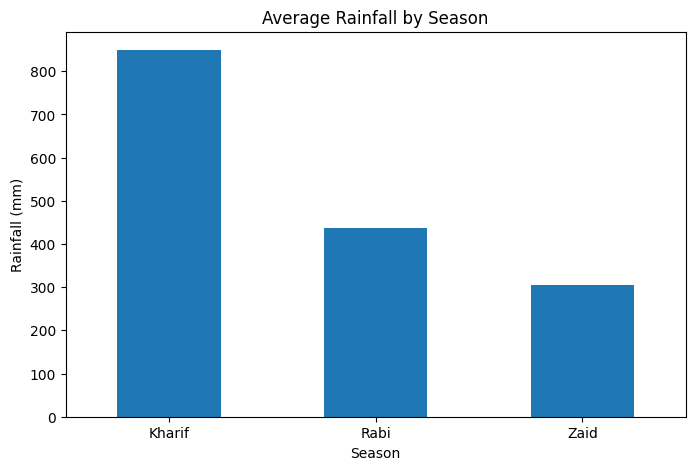

In [21]:
plt.figure(figsize=(8,5))

environment_summary["Average_Rainfall"].plot(kind="bar")

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=0)

plt.show()

## Statistical Analysis

A statistical test is performed to examine whether agricultural yield shows statistically detectable differences across seasons.

In [22]:
groups = [
    clean.loc[clean["Season"] == season, "Yield_Tonnes_Ha"]
    for season in season_order
]

anova_result = stats.f_oneway(*groups)

print("ANOVA statistic:", anova_result.statistic)
print("ANOVA p-value:", anova_result.pvalue)

ANOVA statistic: 1.5438804542488311
ANOVA p-value: 0.21367813841792296


In [23]:
kruskal_result = stats.kruskal(*groups)

print("Kruskal-Wallis statistic:", kruskal_result.statistic)
print("Kruskal-Wallis p-value:", kruskal_result.pvalue)

Kruskal-Wallis statistic: 68.71306722231378
Kruskal-Wallis p-value: 1.1999054760748268e-15


In [24]:
state_season = clean.pivot_table(
    index="State",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean"
).reindex(columns=season_order)

state_season

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.676958,3.470931,4.448000
Gujarat,6.338416,5.441700,4.066716
Karnataka,6.455024,4.567864,6.623243
Madhya Pradesh,5.985265,3.760385,5.478889
Maharashtra,5.430315,5.501927,2.277778
Punjab,4.100633,8.609355,5.909610
Tamil Nadu,5.520534,4.501394,4.097746
Telangana,5.552436,4.784569,4.248471


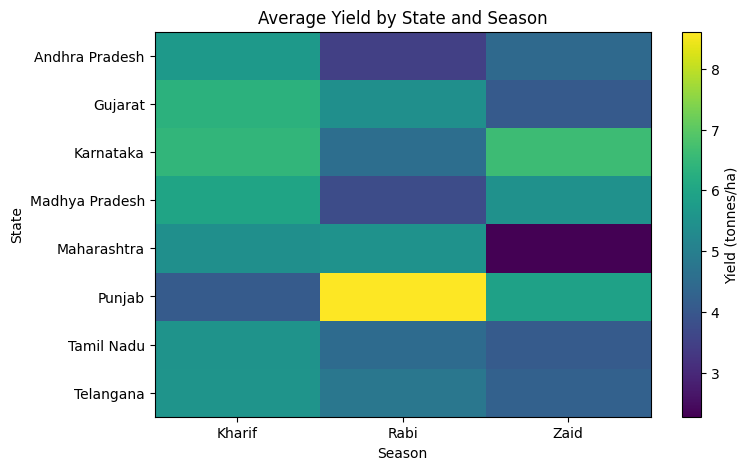

In [25]:
plt.figure(figsize=(8,5))

plt.imshow(state_season.values, aspect="auto")

plt.xticks(
    range(len(state_season.columns)),
    state_season.columns
)

plt.yticks(
    range(len(state_season.index)),
    state_season.index
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")

plt.colorbar(label="Yield (tonnes/ha)")

plt.show()

# 20. Meaningful Insights

### Insight 1 — Seasonal Yield
Kharif records the highest average yield at approximately 5.63 tonnes/ha, while Zaid records the lowest at approximately 4.64 tonnes/ha.

### Insight 2 — Seasonal Profitability
Kharif records the strongest average profitability among the three seasons.

### Insight 3 — Zaid Profitability Challenge
Zaid records a negative average profit, indicating the need for further investigation into its production costs, crop selection, water availability and market conditions.

### Insight 4 — Crop Yield Differences
Sugarcane records the highest average yield in tonnes/ha among the crops in the dataset.

### Insight 5 — Irrigation Performance
Drip irrigation records the highest average yield among the irrigation methods.

### Insight 6 — Drip Profitability
Drip irrigation also records the strongest average profit among the irrigation categories.

### Insight 7 — Water Efficiency
Rainfed farming records the highest water-efficiency metric in the dataset.

### Insight 8 — Yield and Water Efficiency
Yield and water efficiency show a strong positive correlation of approximately 0.91.

### Insight 9 — Environmental Variation
Rainfall, temperature and soil moisture vary considerably across seasons.

### Insight 10 — Regional Variation
The state × season analysis demonstrates that agricultural performance can vary between geographical areas.

# Final Findings

### 1. Seasonal Performance
Kharif recorded the highest average yield, while Zaid recorded the lowest.

### 2. Profitability
Kharif showed the strongest average profitability, whereas Zaid recorded a negative average profit.

### 3. Crop Performance
Sugarcane recorded the highest yield in tonnes/ha among the crops in the dataset.

### 4. Irrigation
Drip irrigation showed the highest average yield and average profit among the irrigation methods analyzed.

### 5. Water Efficiency
Rainfed farming recorded the highest water-efficiency metric in the dataset.

### 6. Relationship Analysis
Yield and water efficiency showed a strong positive correlation of approximately 0.91.

### 7. Environmental Conditions
Rainfall, temperature and soil moisture varied across seasons and provide useful context for interpreting agricultural performance.

# Data-Driven Recommendations

- Use season-specific agricultural planning instead of applying the same strategy throughout the year.
- Consider efficient irrigation practices where economically feasible.
- Investigate the causes of low profitability during the Zaid season.
- Evaluate crop selection using yield, profit and resource efficiency together.
- Monitor water efficiency along with agricultural productivity.
- Use multi-year weather and agricultural data for more reliable planning.
- In the future, machine-learning models can be developed for yield and profit prediction.

# Conclusion

The analysis demonstrates that agricultural performance varies across seasons, crops and irrigation methods.

Kharif showed the strongest overall yield and profitability in the analyzed dataset, while Zaid presented the greatest profitability challenge.

The analysis also identified a strong relationship between yield and water efficiency.

These findings can support better seasonal planning and provide a foundation for future predictive agricultural analytics.

# Limitations

- The analysis is based only on the supplied agricultural dataset.
- The dataset may not represent all farms or agricultural regions.
- Missing numerical values were handled using median imputation.
- Outliers were investigated but retained because they may represent genuine observations.
- Crop yields are naturally different, so tonnes/ha should not be the only basis for comparing crops.
- The dataset is observational, so correlations should not be interpreted as proof of causation.
- Agricultural market prices and weather conditions can change over time.
- Additional multi-year data would improve the reliability of the findings.